#### Effect of Geometric Standard Deviation

Patch A: gm=1.057, gsd=1.071
Patch B: gm=1.016, gsd=1.303


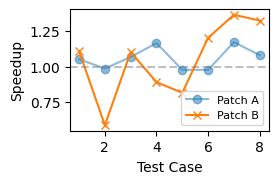

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def gm(x):
    return np.exp(np.mean(np.log(x)))


def gsd(x):
    return np.exp(np.std(np.log(x)))


# ------------- Simulate data for 10 tests -----------------------------------
np.random.seed(42)
n_tests = 8
mu_speedup_A = np.log(1.0)
speedups_A = np.random.lognormal(mu_speedup_A, 0.1, size=n_tests)
# ------- Patch B – resample until gm ≥ 0.95 and gsd > 1.3 -------------------
mu_speedup_B = np.log(1.0)  # centre on 1× (neutral speed‑up)
sigma_B = 0.3  # population gsd = e^σ ≈ 1.57  (>1.3)

while True:
    speedups_B = np.random.lognormal(mu_speedup_B, sigma_B, size=n_tests)
    gm_B = gm(speedups_B)
    gsd_B = gsd(speedups_B)
    if gm_B >= 0.95 and gsd_B > 1.3:
        break


print(f"Patch A: gm={gm(speedups_A):.3f}, gsd={gsd(speedups_A):.3f}")
print(f"Patch B: gm={gm(speedups_B):.3f}, gsd={gsd(speedups_B):.3f}")


# ------------- Single compact plot ------------------------------------------
fig = plt.figure(figsize=(2.8, 2))
ax = fig.add_subplot(111)

ax.plot(range(1, n_tests + 1), speedups_A, marker="o", alpha=0.5, label="Patch A")
ax.plot(range(1, n_tests + 1), speedups_B, marker="x", label="Patch B")

ax.axhline(1, linestyle="--", alpha=0.5, color="gray")
ax.set_xlabel("Test Case")
ax.set_ylabel("Speedup")
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
fig.savefig("plots/metric_design.png", bbox_inches="tight", dpi=300)
plt.show()

Patch A: gm=1.60, gsd=1.19
Patch B: gm=1.17, gsd=2.46


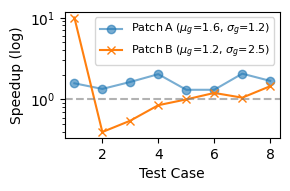

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ------------ parameters -----------------
np.random.seed(42)
n_tests = 8

# Patch A – small, consistent ~1.05× wins
speedups_A = np.random.lognormal(mean=np.log(1.39), sigma=0.25, size=n_tests)

# Patch B – one huge win (≈10×), a few slow‑downs (<1×), and some =1×
speedups_B = np.array([10.0, 0.4, 0.55, 0.85, 1.0, 1.2, 1.05, 1.45])


def gm(x):
    return np.exp(np.mean(np.log(x)))


def gsd(x):
    return np.exp(np.std(np.log(x)))


print(f"Patch A: gm={gm(speedups_A):.2f}, gsd={gsd(speedups_A):.2f}")
print(f"Patch B: gm={gm(speedups_B):.2f}, gsd={gsd(speedups_B):.2f}")

# ------------------ plot ------------------
fig, ax = plt.subplots(figsize=(3.0, 2.0))

ax.plot(
    range(1, n_tests + 1),
    speedups_A,
    marker="o",
    alpha=0.6,
    label=f"Patch A ($\\mu_{{g}}$={gm(speedups_A):.1f}, $\\sigma_{{g}}$={gsd(speedups_A):.1f})",
)
ax.plot(
    range(1, n_tests + 1),
    speedups_B,
    marker="x",
    label=f"Patch B ($\\mu_{{g}}$={gm(speedups_B):.1f}, $\\sigma_{{g}}$={gsd(speedups_B):.1f})",
)

ax.set_yscale("log")
ax.axhline(1, linestyle="--", color="gray", alpha=0.6)
ax.set_xlabel("Test Case")
ax.set_ylabel("Speedup (log)")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
fig.savefig("plots/metric_design.png", bbox_inches="tight", dpi=300)
plt.show()